# Avaliando um modelo de classificação
- No excel **"BaseInadimplencia.xlsx"** temos 2 abas:
    - **treino**: dados de treine
    - **teste**: dados de teste

### Importando e visualizando a base

In [1]:
# Importando o pandas e a base
import pandas as pd
treino = pd.read_excel("BaseInadimplencia.xlsx",sheet_name='treino')
teste = pd.read_excel("BaseInadimplencia.xlsx",sheet_name='teste')

In [2]:
treino.head(2)

,SaldoConta,SaldoInvestimento,Situacao
0,-1.365390,-3.280278,0
1,-3.910816,-0.874096,0


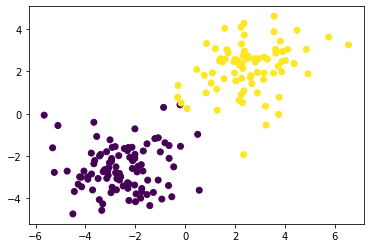

In [3]:
# Criando uma reta capaz de separar esses pontos
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.scatter(teste.SaldoConta, teste.SaldoInvestimento,c=teste.Situacao)

plt.show()

### Criando dois modelos de classificação e utilizando nos dados de teste

In [4]:
# Dados de treino
X_treino = treino.drop('Situacao',axis=1)
y_treino = treino.Situacao

# Dados de teste
X_teste = teste.drop('Situacao',axis=1)
y_teste = teste.Situacao

#### Regressão Logística

In [5]:
# Importando a regressão logística
from sklearn.linear_model import LogisticRegression

# Criando o classificador
clfLR = LogisticRegression(random_state=0).fit(X_treino, y_treino)

# Fazendo o predict nos dados de treino
treino['y_RegLog'] = clfLR.predict(X_treino)

# Fazendo o predict nos dados de teste
teste['y_RegLog'] = clfLR.predict(X_teste)

In [14]:
teste.head(2)

,SaldoConta,SaldoInvestimento,Situacao,y_RegLog
0,-1.992492,-4.158429,0,0
1,-3.306014,-4.261263,0,0


#### Árvore de Decisão

In [15]:
# Importando a árvore de decisão
from sklearn.tree import DecisionTreeClassifier

# Criando o classificador
clfDT = DecisionTreeClassifier(random_state=0).fit(X_treino, y_treino)

# Fazendo o predict nos dados de treino
treino['y_Arvore'] = clfDT.predict(X_treino)

# Fazendo o predict nos dados de teste
teste['y_Arvore'] = clfDT.predict(X_teste)

In [16]:
teste.head(2)

,SaldoConta,SaldoInvestimento,Situacao,y_RegLog,y_Arvore
0,-1.992492,-4.158429,0,0,0
1,-3.306014,-4.261263,0,0,0


### Avaliando o modelo criado
- Para avaliar o modelo, vamos começar utilizando a matriz de confusão (confusion matrix)
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

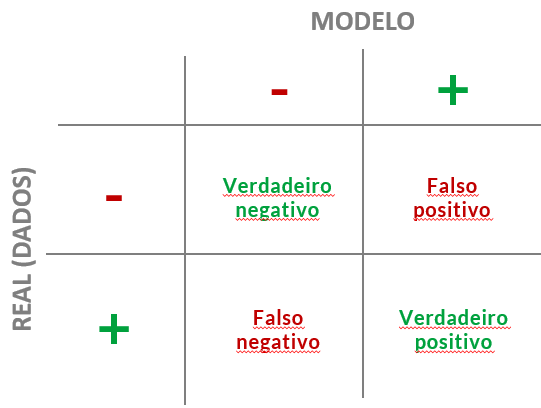

- Vamos calcular a acurácia
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score

- E então vamos utilizar a precisão
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html

- E o recall
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score